In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder

import xgboost as xgb


In [2]:
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')

data = train_transaction.merge(train_identity, how='left', on='TransactionID')

In [3]:
y = data['isFraud']
X = data.drop(['isFraud', 'TransactionID'], axis=1)

In [4]:
print(train_transaction.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   NaN   NaN  

In [5]:
print(train_identity.head())

   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   
3    NaN  ...          chrome 62.0    NaN        NaN             NaN      F   
4    0.0  ...          chrome 62.0   24.0   1280x800  match_status:2      T   

  id_36 id_37  id_38  DeviceType                  

In [6]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

X[cat_cols] = X[cat_cols].fillna('missing')

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[num_cols] = X[num_cols].astype('float32')


In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    model = xgb.XGBClassifier(
        n_estimators=800,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        max_bin=256,
        tree_method='hist',
        device='cuda',
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight
    )

    model.fit(X_train, y_train)

    oof[val_idx] = model.predict_proba(X_val)[:, 1]

    print(f"Fold {fold+1} AUC:", roc_auc_score(y_val, oof[val_idx]))


Fold 1 AUC: 0.9644805223765796
Fold 2 AUC: 0.9680251760344105
Fold 3 AUC: 0.9663896212080161
Fold 4 AUC: 0.9670697413650221
Fold 5 AUC: 0.966499251924402


In [12]:
print("Overall CV AUC:", roc_auc_score(y, oof))


Overall CV AUC: 0.9664824761414169


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

threshold = 0.5
y_pred = (oof >= threshold).astype(int)

cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[555180  14697]
 [  3727  16936]]


In [14]:
print("\nClassification Report:")
print(classification_report(y, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    569877
           1       0.54      0.82      0.65     20663

    accuracy                           0.97    590540
   macro avg       0.76      0.90      0.82    590540
weighted avg       0.98      0.97      0.97    590540



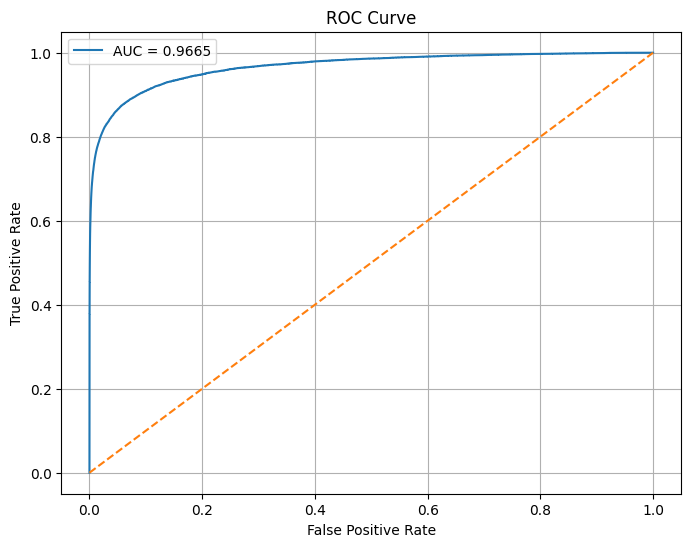

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y, oof)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()
